# Sensitivity Analysis: Hyperparameters and Data Size

This notebook systematically studies how GMM and Flow Matching performance depends on:
1. Training data size
2. Model architecture/hyperparameters
3. Training configuration

**Test Problem:** 1D Optimization - Find optimal residence time τ* for consecutive reactions A → B → C
- Analytical solution: τ* = ln(k₁/k₂)/(k₁-k₂)
- Parameters: k₁=0.5, k₂=0.1, τ* ≈ 4.024

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
    ('pandas', 'pandas'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
pandas               2.2.3
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 13:27:34
Initial memory usage: 317.17 MB


## Setup and Problem Definition

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from tqdm import tqdm

# Force CPU for JAX (must be set before importing JAX)
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch
import jax
import jax.numpy as jnp
from jax import grad, vmap
from sklearn.mixture import GaussianMixture

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    best_gmm,
    ConditionalFlowMatching
)

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12

warnings.filterwarnings('ignore')

print("Setup complete.")

Using device: cpu
Setup complete.


In [3]:
# Problem Definition: 1D Optimization
# Find optimal residence time τ* for A → B → C
# Objective: maximize C_B(τ) = C_A0 * k1/(k2-k1) * (exp(-k1*τ) - exp(-k2*τ))
# Analytical solution: τ* = ln(k1/k2) / (k1 - k2)

k1 = 0.5
k2 = 0.1
tau_analytical = np.log(k1 / k2) / (k1 - k2)

print(f"Problem: Optimize residence time for A → B → C")
print(f"Parameters: k1 = {k1}, k2 = {k2}")
print(f"Analytical solution: τ* = {tau_analytical:.6f}")

# Define objective and derivative using JAX
def C_B(tau, k1=0.5, k2=0.1):
    """Concentration of B (we want to maximize this)."""
    return k1 / (k2 - k1) * (jnp.exp(-k1 * tau) - jnp.exp(-k2 * tau))

def neg_C_B(tau):
    """Negative C_B for minimization."""
    return -C_B(tau[0], k1, k2)

dCB_dtau = grad(neg_C_B)

# Verify derivative is zero at analytical solution
deriv_at_opt = dCB_dtau(jnp.array([tau_analytical]))
print(f"Derivative at τ*: {float(deriv_at_opt[0]):.2e} (should be ≈ 0)")

Problem: Optimize residence time for A → B → C
Parameters: k1 = 0.5, k2 = 0.1
Analytical solution: τ* = 4.023595
Derivative at τ*: 0.00e+00 (should be ≈ 0)


In [4]:
# Helper functions for experiments

def generate_training_data(n_samples, bounds=[[0.5, 10]], seed=42):
    """Generate training data: (τ, dC_B/dτ) pairs."""
    np.random.seed(seed)
    tau_samples = generate_samples(bounds, n_samples=n_samples, seed=seed)
    derivs = np.array([float(dCB_dtau(jnp.array([t]))[0]) for t in tau_samples[:, 0]])
    return tau_samples, derivs.reshape(-1, 1)

def evaluate_gmm(gmm, n_samples=500):
    """Evaluate GMM by conditioning on derivative = 0."""
    try:
        c_gmm = gmm.condition([1], [[0.0]])
        samples = c_gmm.sample(n_samples)
        return samples.flatten()
    except Exception as e:
        return np.array([np.nan])

def evaluate_fm(fm, n_samples=500, n_steps=100):
    """Evaluate Flow Matching by conditioning on derivative = 0."""
    samples = fm.sample(c_values=[[0.0]], n_samples=n_samples, n_steps=n_steps)
    return samples.flatten()

def compute_metrics(samples, true_value):
    """Compute accuracy metrics for sampled solutions."""
    samples = samples[~np.isnan(samples)]  # Remove NaNs
    if len(samples) == 0:
        return {'mae': np.nan, 'std': np.nan, 'pct_within_5pct': np.nan, 'mean': np.nan}
    
    mean = np.mean(samples)
    mae = np.abs(mean - true_value)
    std = np.std(samples)
    tolerance = 0.05 * true_value
    pct_within = 100 * np.mean(np.abs(samples - true_value) < tolerance)
    
    return {
        'mae': mae,
        'std': std,
        'pct_within_5pct': pct_within,
        'mean': mean
    }

print("Helper functions defined.")

Helper functions defined.


## Experiment 1: Data Size Scaling

How does solution accuracy depend on the amount of training data?

In [5]:
# Experiment 1a: GMM - Data Size Scaling
print("Experiment 1a: GMM Data Size Scaling")
print("=" * 60)

gmm_n_samples_list = [50, 100, 200, 500, 1000, 2000]
gmm_results = []

for n in tqdm(gmm_n_samples_list, desc="GMM experiments"):
    t_start = time.time()
    
    # Generate data
    tau_data, deriv_data = generate_training_data(n, seed=42)
    data = np.column_stack([tau_data, deriv_data])
    
    # Train GMM
    gmm, info = best_gmm(data, verbose=False)
    
    # Evaluate
    samples = evaluate_gmm(gmm)
    metrics = compute_metrics(samples, tau_analytical)
    
    t_elapsed = time.time() - t_start
    
    gmm_results.append({
        'n_samples': n,
        'n_components': info['best_k'],
        'mae': metrics['mae'],
        'std': metrics['std'],
        'pct_within_5pct': metrics['pct_within_5pct'],
        'mean': metrics['mean'],
        'time_s': t_elapsed
    })

gmm_df = pd.DataFrame(gmm_results)
print("\nGMM Results:")
print(gmm_df.to_string(index=False))

Experiment 1a: GMM Data Size Scaling


GMM experiments:   0%|          | 0/6 [00:00<?, ?it/s]

GMM experiments:  17%|█▋        | 1/6 [00:00<00:00,  8.08it/s]

GMM experiments:  33%|███▎      | 2/6 [00:00<00:00,  4.85it/s]

GMM experiments:  50%|█████     | 3/6 [00:01<00:01,  2.54it/s]

GMM experiments:  67%|██████▋   | 4/6 [00:01<00:01,  1.67it/s]

GMM experiments:  83%|████████▎ | 5/6 [00:03<00:01,  1.07s/it]

GMM experiments: 100%|██████████| 6/6 [00:07<00:00,  1.92s/it]

GMM experiments: 100%|██████████| 6/6 [00:07<00:00,  1.23s/it]


GMM Results:
 n_samples  n_components      mae      std  pct_within_5pct     mean   time_s
        50             6 0.051634 0.090785             97.2 4.075229 0.123786
       100             7 0.029961 0.054204             98.8 4.053556 0.262870
       200            12 0.014253 0.037815            100.0 4.037848 0.616679
       500            13 0.012383 0.038112            100.0 4.035978 0.913626
      1000            18 0.000445 0.037184            100.0 4.023150 1.892905
      2000            18 0.002017 0.029931            100.0 4.021577 3.575369


In [6]:
# Experiment 1b: Flow Matching - Data Size Scaling
print("Experiment 1b: Flow Matching Data Size Scaling")
print("=" * 60)

fm_n_samples_list = [100, 250, 500, 1000, 2000, 5000]
fm_results = []

for n in tqdm(fm_n_samples_list, desc="FM experiments"):
    t_start = time.time()
    
    # Generate data
    torch.manual_seed(42)
    np.random.seed(42)
    tau_data, deriv_data = generate_training_data(n, seed=42)
    
    # Train Flow Matching
    fm = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4, sigma_min=0.001)
    fm.fit(tau_data, deriv_data, epochs=500, batch_size=min(64, n//2), verbose=False)
    
    # Evaluate
    samples = evaluate_fm(fm)
    metrics = compute_metrics(samples, tau_analytical)
    
    t_elapsed = time.time() - t_start
    
    fm_results.append({
        'n_samples': n,
        'mae': metrics['mae'],
        'std': metrics['std'],
        'pct_within_5pct': metrics['pct_within_5pct'],
        'mean': metrics['mean'],
        'time_s': t_elapsed
    })

fm_df = pd.DataFrame(fm_results)
print("\nFlow Matching Results:")
print(fm_df.to_string(index=False))

Experiment 1b: Flow Matching Data Size Scaling


FM experiments:   0%|          | 0/6 [00:00<?, ?it/s]

FM experiments:  17%|█▋        | 1/6 [00:04<00:21,  4.39s/it]

FM experiments:  33%|███▎      | 2/6 [00:09<00:18,  4.56s/it]

FM experiments:  50%|█████     | 3/6 [00:14<00:15,  5.18s/it]

FM experiments:  67%|██████▋   | 4/6 [00:23<00:12,  6.46s/it]

FM experiments:  83%|████████▎ | 5/6 [00:37<00:09,  9.09s/it]

FM experiments: 100%|██████████| 6/6 [01:22<00:00, 21.28s/it]

FM experiments: 100%|██████████| 6/6 [01:22<00:00, 13.68s/it]


Flow Matching Results:
 n_samples      mae      std  pct_within_5pct     mean    time_s
       100 0.087964 0.152687             75.2 3.935631  4.387780
       250 0.007608 0.099907             95.6 4.031202  4.671736
       500 0.012810 0.060236             99.6 4.036405  5.918706
      1000 0.037560 0.051075             99.4 4.061154  8.417354
      2000 0.010509 0.037878            100.0 4.013085 13.745487
      5000 0.003745 0.014849            100.0 4.027339 44.964555


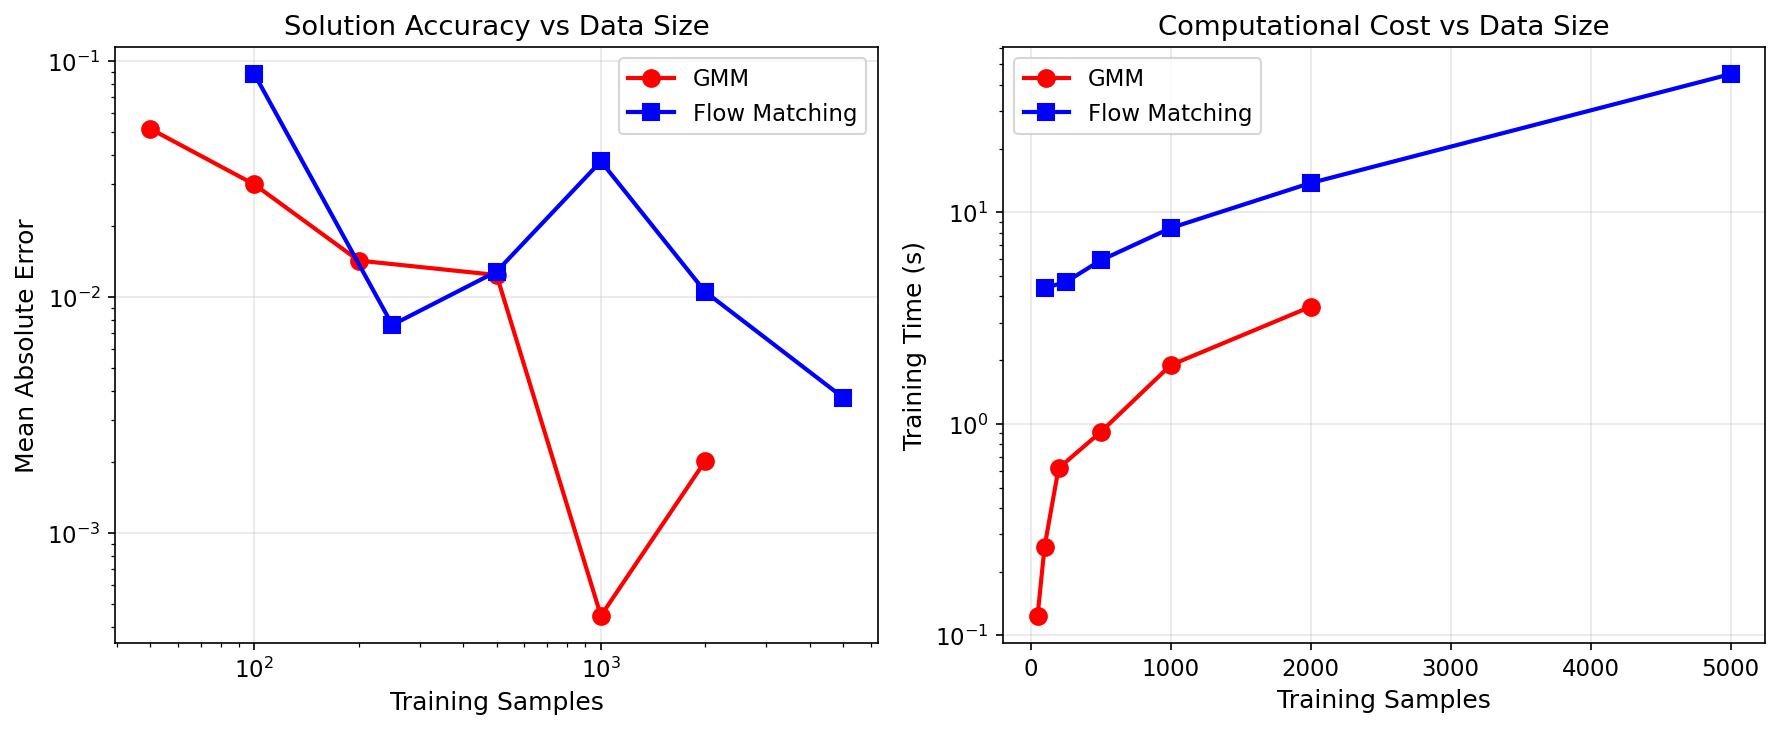


Analytical solution: τ* = 4.0236


In [7]:
# Plot Experiment 1 Results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: MAE vs n_samples (log-log)
ax = axes[0]
ax.loglog(gmm_df['n_samples'], gmm_df['mae'], 'ro-', label='GMM', linewidth=2, markersize=8)
ax.loglog(fm_df['n_samples'], fm_df['mae'], 'bs-', label='Flow Matching', linewidth=2, markersize=8)
ax.set_xlabel('Training Samples')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Solution Accuracy vs Data Size')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Training time vs n_samples
ax = axes[1]
ax.semilogy(gmm_df['n_samples'], gmm_df['time_s'], 'ro-', label='GMM', linewidth=2, markersize=8)
ax.semilogy(fm_df['n_samples'], fm_df['time_s'], 'bs-', label='Flow Matching', linewidth=2, markersize=8)
ax.set_xlabel('Training Samples')
ax.set_ylabel('Training Time (s)')
ax.set_title('Computational Cost vs Data Size')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

print(f"\nAnalytical solution: τ* = {tau_analytical:.4f}")

## Experiment 2: GMM Component Selection

How does the number of Gaussian components affect GMM performance?

In [8]:
# Experiment 2: GMM Component Selection
print("Experiment 2: GMM Component Selection")
print("=" * 60)

# Fixed data size
n_train = 500
tau_data, deriv_data = generate_training_data(n_train, seed=42)
data = np.column_stack([tau_data, deriv_data])

# Test different forced component numbers
k_values = [2, 3, 5, 7, 10, 15, 20, 30]
component_results = []

from gmr import GMM as GMR_GMM

for k in tqdm(k_values, desc="Testing k values"):
    t_start = time.time()
    
    # Train GMM with fixed k
    gmm_fixed = GaussianMixture(n_components=k, covariance_type='full', 
                                 n_init=3, reg_covar=1e-6, random_state=42)
    gmm_fixed.fit(data)
    bic = gmm_fixed.bic(data)
    
    # Wrap for conditioning - initialize GMR GMM directly with sklearn parameters
    gmr_gmm = GMR_GMM(
        n_components=k,
        priors=gmm_fixed.weights_,
        means=gmm_fixed.means_,
        covariances=gmm_fixed.covariances_
    )
    
    # Evaluate
    samples = evaluate_gmm(gmr_gmm)
    metrics = compute_metrics(samples, tau_analytical)
    
    t_elapsed = time.time() - t_start
    
    component_results.append({
        'k': k,
        'bic': bic,
        'mae': metrics['mae'],
        'std': metrics['std'],
        'pct_within_5pct': metrics['pct_within_5pct'],
        'mean': metrics['mean'],
        'time_s': t_elapsed
    })

# Also run with BIC-selected k
gmm_auto, info_auto = best_gmm(data, verbose=False)
samples_auto = evaluate_gmm(gmm_auto)
metrics_auto = compute_metrics(samples_auto, tau_analytical)

component_df = pd.DataFrame(component_results)
print("\nResults by Component Count:")
print(component_df.to_string(index=False))
print(f"\nBIC-selected k = {info_auto['best_k']}, MAE = {metrics_auto['mae']:.6f}")

Experiment 2: GMM Component Selection


Testing k values:   0%|          | 0/8 [00:00<?, ?it/s]

Testing k values:  88%|████████▊ | 7/8 [00:00<00:00, 67.69it/s]

Testing k values: 100%|██████████| 8/8 [00:00<00:00, 62.09it/s]


Results by Component Count:
 k          bic      mae      std  pct_within_5pct     mean   time_s
 2  -738.640654 0.062209 0.433626             33.8 3.961386 0.005966
 3 -1578.302783 0.066141 0.290023             60.4 3.957453 0.006831
 5 -2421.763912 0.023195 0.115039             90.8 4.000400 0.025587
 7 -2653.603250 0.031039 0.084344             98.2 4.054634 0.008003
10 -2981.932588 0.005214 0.049311            100.0 4.018380 0.011316
15 -3030.092638 0.002558 0.035695            100.0 4.021037 0.023833
20 -2977.687432 0.001947 0.030736            100.0 4.025542 0.021854
30 -2660.729721 0.002579 0.033376            100.0 4.026173 0.024979

BIC-selected k = 13, MAE = 0.013388


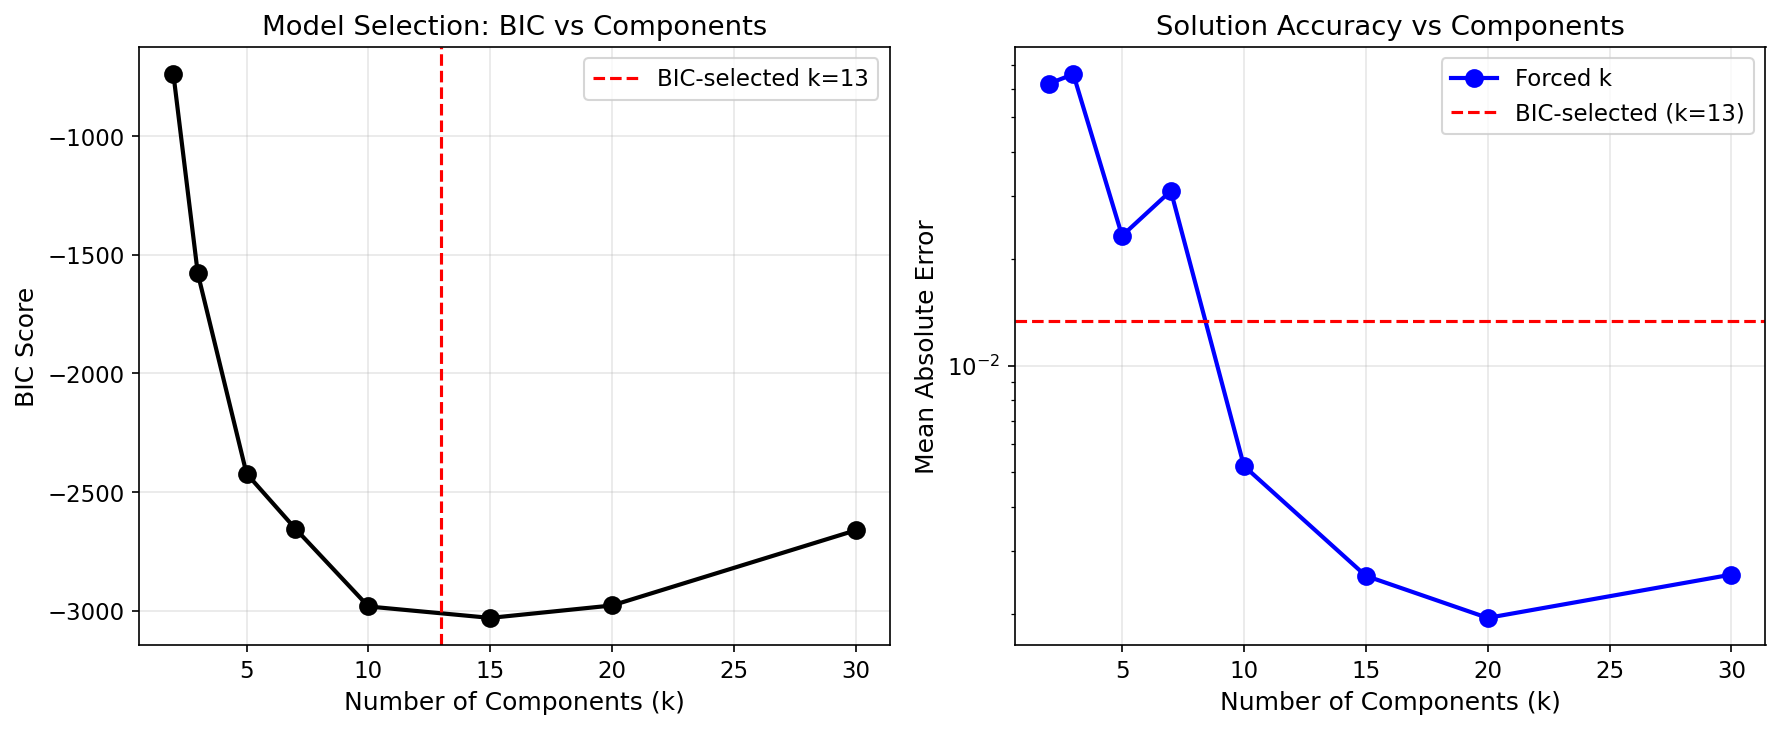

In [9]:
# Plot Experiment 2 Results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: BIC vs k
ax = axes[0]
ax.plot(component_df['k'], component_df['bic'], 'ko-', linewidth=2, markersize=8)
ax.axvline(info_auto['best_k'], color='r', linestyle='--', label=f'BIC-selected k={info_auto["best_k"]}')
ax.set_xlabel('Number of Components (k)')
ax.set_ylabel('BIC Score')
ax.set_title('Model Selection: BIC vs Components')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: MAE vs k
ax = axes[1]
ax.semilogy(component_df['k'], component_df['mae'], 'bo-', linewidth=2, markersize=8, label='Forced k')
ax.axhline(metrics_auto['mae'], color='r', linestyle='--', label=f'BIC-selected (k={info_auto["best_k"]})')
ax.set_xlabel('Number of Components (k)')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Solution Accuracy vs Components')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

## Experiment 3: Flow Matching Architecture

How do hidden_dim and n_layers affect Flow Matching performance?

In [10]:
# Experiment 3: FM Architecture Grid Search
print("Experiment 3: Flow Matching Architecture")
print("=" * 60)

# Fixed data
n_train = 1000
tau_data, deriv_data = generate_training_data(n_train, seed=42)

hidden_dims = [32, 64, 128, 256]
n_layers_list = [2, 3, 4, 5]

arch_results = []
total = len(hidden_dims) * len(n_layers_list)

with tqdm(total=total, desc="Architecture grid") as pbar:
    for h in hidden_dims:
        for nl in n_layers_list:
            t_start = time.time()
            
            torch.manual_seed(42)
            np.random.seed(42)
            
            # Train
            fm = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=h, n_layers=nl, sigma_min=0.001)
            history = fm.fit(tau_data, deriv_data, epochs=500, batch_size=64, verbose=False)
            
            # Count parameters
            n_params = sum(p.numel() for p in fm.model.parameters())
            
            # Get final loss from history dict
            final_loss = history['loss'][-1] if history and 'loss' in history and len(history['loss']) > 0 else np.nan
            
            # Evaluate
            samples = evaluate_fm(fm)
            metrics = compute_metrics(samples, tau_analytical)
            
            t_elapsed = time.time() - t_start
            
            arch_results.append({
                'hidden_dim': h,
                'n_layers': nl,
                'n_params': n_params,
                'final_loss': final_loss,
                'mae': metrics['mae'],
                'std': metrics['std'],
                'pct_within_5pct': metrics['pct_within_5pct'],
                'time_s': t_elapsed
            })
            pbar.update(1)

arch_df = pd.DataFrame(arch_results)
print("\nArchitecture Results:")
print(arch_df.to_string(index=False))

Experiment 3: Flow Matching Architecture


Architecture grid:   0%|          | 0/16 [00:00<?, ?it/s]

Architecture grid:   6%|▋         | 1/16 [00:03<00:50,  3.34s/it]

Architecture grid:  12%|█▎        | 2/16 [00:07<00:51,  3.66s/it]

Architecture grid:  19%|█▉        | 3/16 [00:11<00:52,  4.02s/it]

...

Architecture grid:  88%|████████▊ | 14/16 [01:26<00:18,  9.21s/it]

Architecture grid:  94%|█████████▍| 15/16 [01:42<00:11, 11.05s/it]

Architecture grid: 100%|██████████| 16/16 [02:01<00:00, 13.65s/it]

Architecture grid: 100%|██████████| 16/16 [02:01<00:00,  7.61s/it]


Architecture Results:
 hidden_dim  n_layers  n_params  final_loss      mae      std  pct_within_5pct    time_s
         32         2      1217    0.339643 0.067991 0.171379             75.2  3.339364
         32         3      2273    0.334814 0.031827 0.158306             82.6  3.883863
         32         4      3329    0.298410 0.022050 0.085449             94.2  4.457403
         32         5      4385    0.257159 0.007441 0.045133             99.4  5.007871
         64         2      4481    0.276484 0.053619 0.139862             87.2  3.879455
         64         3      8641    0.247243 0.000743 0.071175             98.4  4.669476
         64         4     12801    0.249314 0.010217 0.055211             99.8  5.598537
         64         5     16961    0.223081 0.005016 0.036626            100.0  6.460954
        128         2     17153    0.276585 0.011349 0.138717             88.4  4.908424
        128         3     33665    0.238255 0.007762 0.049879             99.6  6.24610

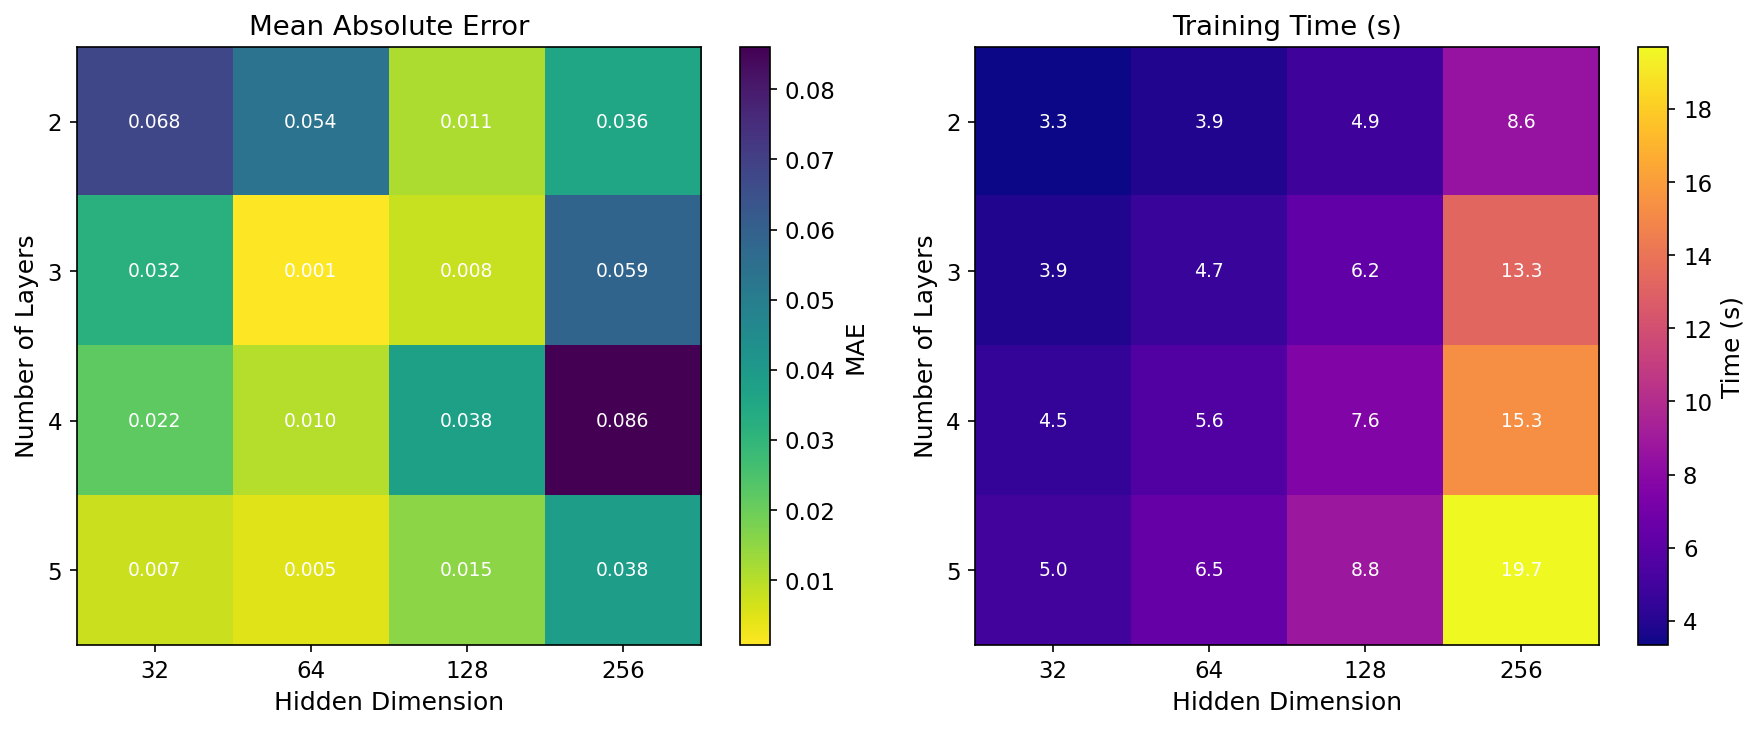

In [11]:
# Plot Experiment 3 Results as Heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Reshape for heatmap
mae_matrix = arch_df.pivot(index='n_layers', columns='hidden_dim', values='mae')
time_matrix = arch_df.pivot(index='n_layers', columns='hidden_dim', values='time_s')

# Left: MAE heatmap
ax = axes[0]
im = ax.imshow(mae_matrix.values, cmap='viridis_r', aspect='auto')
ax.set_xticks(range(len(hidden_dims)))
ax.set_xticklabels(hidden_dims)
ax.set_yticks(range(len(n_layers_list)))
ax.set_yticklabels(n_layers_list)
ax.set_xlabel('Hidden Dimension')
ax.set_ylabel('Number of Layers')
ax.set_title('Mean Absolute Error')
plt.colorbar(im, ax=ax, label='MAE')

# Add text annotations
for i in range(len(n_layers_list)):
    for j in range(len(hidden_dims)):
        text = ax.text(j, i, f'{mae_matrix.values[i, j]:.3f}',
                       ha='center', va='center', color='white', fontsize=9)

# Right: Training time heatmap
ax = axes[1]
im = ax.imshow(time_matrix.values, cmap='plasma', aspect='auto')
ax.set_xticks(range(len(hidden_dims)))
ax.set_xticklabels(hidden_dims)
ax.set_yticks(range(len(n_layers_list)))
ax.set_yticklabels(n_layers_list)
ax.set_xlabel('Hidden Dimension')
ax.set_ylabel('Number of Layers')
ax.set_title('Training Time (s)')
plt.colorbar(im, ax=ax, label='Time (s)')

# Add text annotations
for i in range(len(n_layers_list)):
    for j in range(len(hidden_dims)):
        text = ax.text(j, i, f'{time_matrix.values[i, j]:.1f}',
                       ha='center', va='center', color='white', fontsize=9)

plt.tight_layout()

## Experiment 4: Training Configuration

How do epochs, batch_size, and sigma_min affect Flow Matching convergence?

In [12]:
# Experiment 4a: Epochs
print("Experiment 4a: Effect of Training Epochs")
print("=" * 60)

n_train = 1000
tau_data, deriv_data = generate_training_data(n_train, seed=42)

epochs_list = [100, 250, 500, 1000, 2000]
epochs_results = []

for epochs in tqdm(epochs_list, desc="Epochs"):
    t_start = time.time()
    
    torch.manual_seed(42)
    np.random.seed(42)
    
    fm = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4, sigma_min=0.001)
    history = fm.fit(tau_data, deriv_data, epochs=epochs, batch_size=64, verbose=False)
    
    samples = evaluate_fm(fm)
    metrics = compute_metrics(samples, tau_analytical)
    
    t_elapsed = time.time() - t_start
    
    epochs_results.append({
        'epochs': epochs,
        'final_loss': history['loss'][-1] if history['loss'] else np.nan,
        'mae': metrics['mae'],
        'std': metrics['std'],
        'time_s': t_elapsed
    })

epochs_df = pd.DataFrame(epochs_results)
print(epochs_df.to_string(index=False))

Experiment 4a: Effect of Training Epochs


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epochs:  20%|██        | 1/5 [00:02<00:08,  2.03s/it]

Epochs:  40%|████      | 2/5 [00:06<00:10,  3.38s/it]

Epochs:  60%|██████    | 3/5 [00:14<00:10,  5.46s/it]

Epochs:  80%|████████  | 4/5 [00:29<00:09,  9.48s/it]

Epochs: 100%|██████████| 5/5 [01:00<00:00, 17.24s/it]

Epochs: 100%|██████████| 5/5 [01:00<00:00, 12.19s/it]

 epochs  final_loss      mae      std    time_s
    100    0.275898 0.003455 0.096177  2.031346
    250    0.317259 0.050185 0.099896  4.318193
    500    0.206140 0.037560 0.051075  7.937241
   1000    0.195722 0.014946 0.025054 15.631081
   2000    0.154504 0.014252 0.019047 31.009279


In [13]:
# Experiment 4b: Batch Size
print("\nExperiment 4b: Effect of Batch Size")
print("=" * 60)

batch_sizes = [32, 64, 128, 256]
batch_results = []

for bs in tqdm(batch_sizes, desc="Batch size"):
    t_start = time.time()
    
    torch.manual_seed(42)
    np.random.seed(42)
    
    fm = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4, sigma_min=0.001)
    history = fm.fit(tau_data, deriv_data, epochs=500, batch_size=bs, verbose=False)
    
    samples = evaluate_fm(fm)
    metrics = compute_metrics(samples, tau_analytical)
    
    t_elapsed = time.time() - t_start
    
    batch_results.append({
        'batch_size': bs,
        'final_loss': history['loss'][-1] if history['loss'] else np.nan,
        'mae': metrics['mae'],
        'std': metrics['std'],
        'time_s': t_elapsed
    })

batch_df = pd.DataFrame(batch_results)
print(batch_df.to_string(index=False))


Experiment 4b: Effect of Batch Size


Batch size:   0%|          | 0/4 [00:00<?, ?it/s]

Batch size:  25%|██▌       | 1/4 [00:11<00:33, 11.08s/it]

Batch size:  50%|█████     | 2/4 [00:19<00:18,  9.40s/it]

Batch size:  75%|███████▌  | 3/4 [00:26<00:08,  8.25s/it]

Batch size: 100%|██████████| 4/4 [00:32<00:00,  7.41s/it]

Batch size: 100%|██████████| 4/4 [00:32<00:00,  8.08s/it]

 batch_size  final_loss      mae      std    time_s
         32    0.211405 0.016249 0.071169 11.084595
         64    0.206140 0.037560 0.051075  8.214879
        128    0.257373 0.020640 0.036189  6.892122
        256    0.271596 0.048543 0.087956  6.128001


In [14]:
# Experiment 4c: sigma_min
print("\nExperiment 4c: Effect of sigma_min")
print("=" * 60)

sigma_mins = [0.0001, 0.001, 0.01, 0.1]
sigma_results = []

for sigma in tqdm(sigma_mins, desc="sigma_min"):
    t_start = time.time()
    
    torch.manual_seed(42)
    np.random.seed(42)
    
    fm = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4, sigma_min=sigma)
    history = fm.fit(tau_data, deriv_data, epochs=500, batch_size=64, verbose=False)
    
    samples = evaluate_fm(fm)
    metrics = compute_metrics(samples, tau_analytical)
    
    t_elapsed = time.time() - t_start
    
    sigma_results.append({
        'sigma_min': sigma,
        'final_loss': history['loss'][-1] if history['loss'] else np.nan,
        'mae': metrics['mae'],
        'std': metrics['std'],
        'time_s': t_elapsed
    })

sigma_df = pd.DataFrame(sigma_results)
print(sigma_df.to_string(index=False))


Experiment 4c: Effect of sigma_min


sigma_min:   0%|          | 0/4 [00:00<?, ?it/s]

sigma_min:  25%|██▌       | 1/4 [00:08<00:24,  8.05s/it]

sigma_min:  50%|█████     | 2/4 [00:16<00:16,  8.44s/it]

sigma_min:  75%|███████▌  | 3/4 [00:25<00:08,  8.38s/it]

sigma_min: 100%|██████████| 4/4 [00:33<00:00,  8.30s/it]

sigma_min: 100%|██████████| 4/4 [00:33<00:00,  8.31s/it]

 sigma_min  final_loss     mae      std   time_s
    0.0001     0.20614 0.03756 0.051075 8.054252
    0.0010     0.20614 0.03756 0.051075 8.701515
    0.0100     0.20614 0.03756 0.051075 8.306478
    0.1000     0.20614 0.03756 0.051075 8.170039


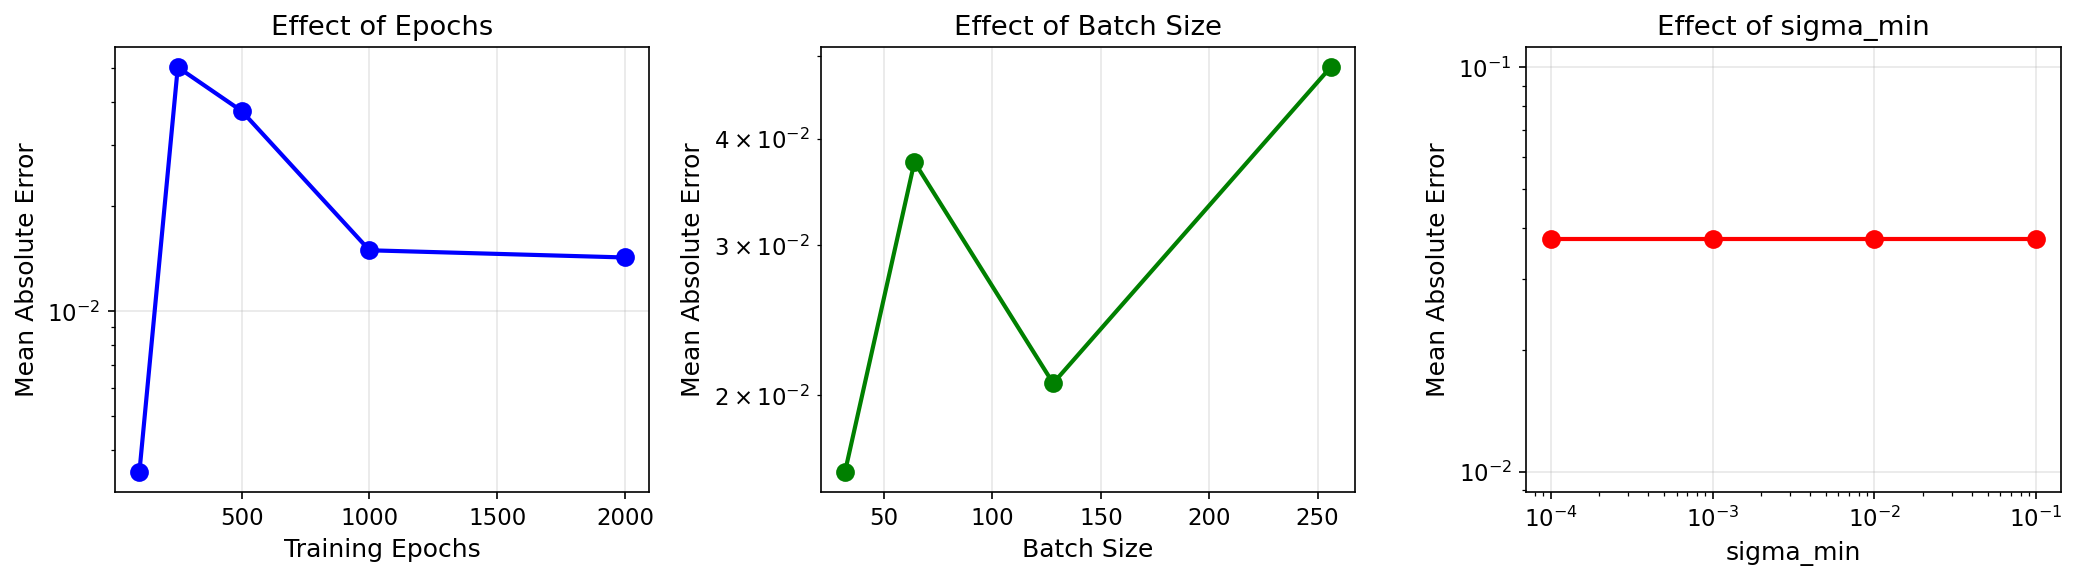

In [15]:
# Plot Experiment 4 Results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Epochs
ax = axes[0]
ax.semilogy(epochs_df['epochs'], epochs_df['mae'], 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Training Epochs')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Effect of Epochs')
ax.grid(True, alpha=0.3)

# Batch size
ax = axes[1]
ax.semilogy(batch_df['batch_size'], batch_df['mae'], 'go-', linewidth=2, markersize=8)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Effect of Batch Size')
ax.grid(True, alpha=0.3)

# sigma_min
ax = axes[2]
ax.loglog(sigma_df['sigma_min'], sigma_df['mae'], 'ro-', linewidth=2, markersize=8)
ax.set_xlabel('sigma_min')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Effect of sigma_min')
ax.grid(True, alpha=0.3)

plt.tight_layout()

## Experiment 5: Reproducibility Analysis

How variable are results across different random seeds?

In [16]:
# Experiment 5: Reproducibility across seeds
print("Experiment 5: Reproducibility Analysis")
print("=" * 60)

seeds = list(range(10))
n_train = 500

gmm_seed_results = []
fm_seed_results = []

for seed in tqdm(seeds, desc="Seeds"):
    # GMM
    tau_data, deriv_data = generate_training_data(n_train, seed=seed)
    data = np.column_stack([tau_data, deriv_data])
    gmm, info = best_gmm(data, verbose=False)
    samples_gmm = evaluate_gmm(gmm)
    metrics_gmm = compute_metrics(samples_gmm, tau_analytical)
    gmm_seed_results.append({
        'seed': seed,
        'method': 'GMM',
        'mae': metrics_gmm['mae'],
        'mean': metrics_gmm['mean'],
        'std': metrics_gmm['std']
    })
    
    # Flow Matching
    torch.manual_seed(seed)
    np.random.seed(seed)
    tau_data, deriv_data = generate_training_data(n_train, seed=seed)
    fm = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4, sigma_min=0.001)
    fm.fit(tau_data, deriv_data, epochs=500, batch_size=64, verbose=False)
    samples_fm = evaluate_fm(fm)
    metrics_fm = compute_metrics(samples_fm, tau_analytical)
    fm_seed_results.append({
        'seed': seed,
        'method': 'FM',
        'mae': metrics_fm['mae'],
        'mean': metrics_fm['mean'],
        'std': metrics_fm['std']
    })

gmm_seed_df = pd.DataFrame(gmm_seed_results)
fm_seed_df = pd.DataFrame(fm_seed_results)

print("\nGMM Reproducibility:")
print(f"  MAE: {gmm_seed_df['mae'].mean():.4f} ± {gmm_seed_df['mae'].std():.4f}")
print(f"  Mean τ: {gmm_seed_df['mean'].mean():.4f} ± {gmm_seed_df['mean'].std():.4f}")

print("\nFlow Matching Reproducibility:")
print(f"  MAE: {fm_seed_df['mae'].mean():.4f} ± {fm_seed_df['mae'].std():.4f}")
print(f"  Mean τ: {fm_seed_df['mean'].mean():.4f} ± {fm_seed_df['mean'].std():.4f}")

print(f"\nAnalytical τ*: {tau_analytical:.4f}")

Experiment 5: Reproducibility Analysis


Seeds:   0%|          | 0/10 [00:00<?, ?it/s]

Seeds:  10%|█         | 1/10 [00:07<01:09,  7.67s/it]

Seeds:  20%|██        | 2/10 [00:15<01:01,  7.75s/it]

Seeds:  30%|███       | 3/10 [00:23<00:53,  7.67s/it]

...

Seeds:  80%|████████  | 8/10 [01:00<00:15,  7.52s/it]

Seeds:  90%|█████████ | 9/10 [01:08<00:07,  7.59s/it]

Seeds: 100%|██████████| 10/10 [01:15<00:00,  7.54s/it]

Seeds: 100%|██████████| 10/10 [01:15<00:00,  7.60s/it]


GMM Reproducibility:
  MAE: 0.0082 ± 0.0055
  Mean τ: 4.0240 ± 0.0102

Flow Matching Reproducibility:
  MAE: 0.0182 ± 0.0121
  Mean τ: 4.0418 ± 0.0121

Analytical τ*: 4.0236


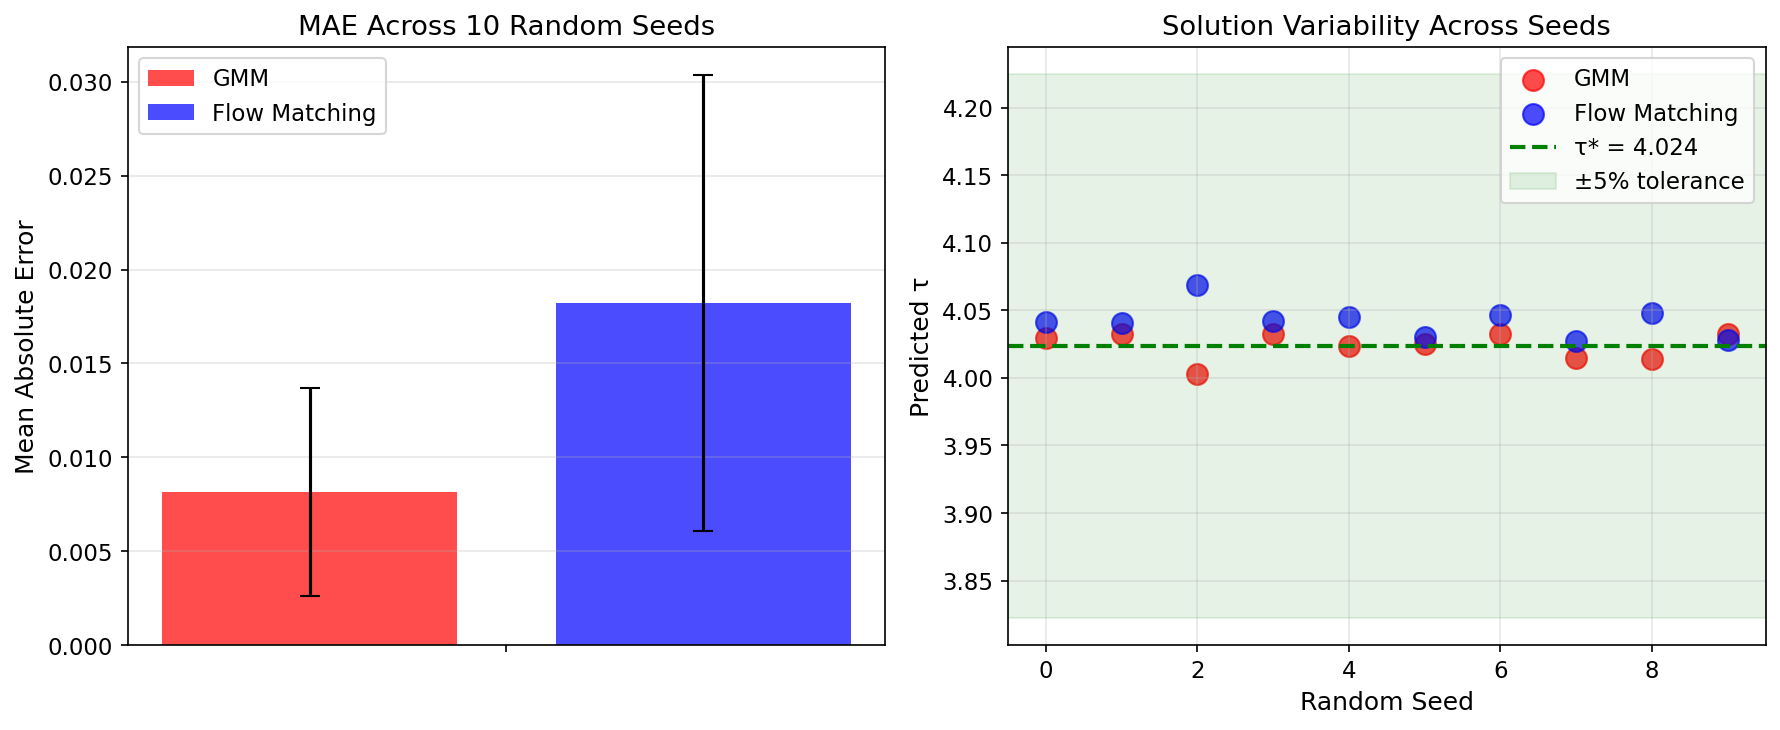

In [17]:
# Plot Experiment 5 Results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: MAE distribution
ax = axes[0]
ax.bar([0], [gmm_seed_df['mae'].mean()], yerr=[gmm_seed_df['mae'].std()], 
       width=0.3, color='red', alpha=0.7, label='GMM', capsize=5)
ax.bar([0.4], [fm_seed_df['mae'].mean()], yerr=[fm_seed_df['mae'].std()], 
       width=0.3, color='blue', alpha=0.7, label='Flow Matching', capsize=5)
ax.set_xticks([0.2])
ax.set_xticklabels([''])
ax.set_ylabel('Mean Absolute Error')
ax.set_title('MAE Across 10 Random Seeds')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Right: Solution distribution
ax = axes[1]
ax.scatter(gmm_seed_df['seed'], gmm_seed_df['mean'], c='red', s=100, label='GMM', alpha=0.7)
ax.scatter(fm_seed_df['seed'], fm_seed_df['mean'], c='blue', s=100, label='Flow Matching', alpha=0.7)
ax.axhline(tau_analytical, color='green', linestyle='--', linewidth=2, label=f'τ* = {tau_analytical:.3f}')
ax.fill_between([-0.5, 9.5], tau_analytical*0.95, tau_analytical*1.05, 
                color='green', alpha=0.1, label='±5% tolerance')
ax.set_xlabel('Random Seed')
ax.set_ylabel('Predicted τ')
ax.set_title('Solution Variability Across Seeds')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 9.5)

plt.tight_layout()

## Summary and Recommendations

In [18]:
print("="*70)
print("SUMMARY: KEY FINDINGS")
print("="*70)

print("\n1. DATA SIZE SCALING")
print("-"*70)
print(f"   GMM: Best MAE = {gmm_df['mae'].min():.4f} at n={gmm_df.loc[gmm_df['mae'].idxmin(), 'n_samples']}")
print(f"   FM:  Best MAE = {fm_df['mae'].min():.4f} at n={fm_df.loc[fm_df['mae'].idxmin(), 'n_samples']}")
print("   Recommendation: GMM works well with 200-500 samples; FM benefits from 1000+")

print("\n2. GMM COMPONENT SELECTION")
print("-"*70)
best_k = component_df.loc[component_df['mae'].idxmin(), 'k']
bic_k = info_auto['best_k']
print(f"   Lowest MAE at k = {best_k}")
print(f"   BIC selected k = {bic_k}")
print("   Recommendation: BIC selection is generally reliable")

print("\n3. FLOW MATCHING ARCHITECTURE")
print("-"*70)
best_arch = arch_df.loc[arch_df['mae'].idxmin()]
print(f"   Best: hidden_dim={int(best_arch['hidden_dim'])}, n_layers={int(best_arch['n_layers'])}")
print(f"   MAE = {best_arch['mae']:.4f}")
print("   Recommendation: hidden_dim=128, n_layers=4 is a robust default")

print("\n4. TRAINING CONFIGURATION")
print("-"*70)
best_epochs = epochs_df.loc[epochs_df['mae'].idxmin(), 'epochs']
best_batch = batch_df.loc[batch_df['mae'].idxmin(), 'batch_size']
best_sigma = sigma_df.loc[sigma_df['mae'].idxmin(), 'sigma_min']
print(f"   Best epochs: {best_epochs}")
print(f"   Best batch_size: {best_batch}")
print(f"   Best sigma_min: {best_sigma}")
print("   Recommendation: 500-1000 epochs, batch_size=64, sigma_min=0.001")

print("\n5. REPRODUCIBILITY")
print("-"*70)
print(f"   GMM MAE: {gmm_seed_df['mae'].mean():.4f} ± {gmm_seed_df['mae'].std():.4f}")
print(f"   FM MAE:  {fm_seed_df['mae'].mean():.4f} ± {fm_seed_df['mae'].std():.4f}")
print("   Both methods show reasonable reproducibility")

print("\n" + "="*70)
print("PRACTICAL GUIDELINES")
print("="*70)
print("""
For GMM:
  - Use 200-500 training samples for simple problems
  - Let BIC select the number of components
  - Fast training (<1s), good for quick exploration

For Flow Matching:
  - Use 1000+ training samples for best accuracy
  - Default architecture: hidden_dim=128, n_layers=4
  - Train for 500-1000 epochs with batch_size=64
  - Use sigma_min=0.001 for precision
  - Slower training (5-15s), but often more accurate
""")

SUMMARY: KEY FINDINGS

1. DATA SIZE SCALING
----------------------------------------------------------------------
   GMM: Best MAE = 0.0004 at n=1000
   FM:  Best MAE = 0.0037 at n=5000
   Recommendation: GMM works well with 200-500 samples; FM benefits from 1000+

2. GMM COMPONENT SELECTION
----------------------------------------------------------------------
   Lowest MAE at k = 20
   BIC selected k = 13
   Recommendation: BIC selection is generally reliable

3. FLOW MATCHING ARCHITECTURE
----------------------------------------------------------------------
   Best: hidden_dim=64, n_layers=3
   MAE = 0.0007
   Recommendation: hidden_dim=128, n_layers=4 is a robust default

4. TRAINING CONFIGURATION
----------------------------------------------------------------------
   Best epochs: 100
   Best batch_size: 32
   Best sigma_min: 0.0001
   Recommendation: 500-1000 epochs, batch_size=64, sigma_min=0.001

5. REPRODUCIBILITY
------------------------------------------------------------

In [19]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 13:27:34
End time:        2025-12-18 13:34:33
Elapsed time:    419.43 seconds (6.99 minutes)
----------------------------------------------------------------------
Initial memory:  317.17 MB
Final memory:    865.27 MB
Memory change:   +548.09 MB
